In [73]:
from sentence_transformers import SentenceTransformer
import hdbscan
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import sqlite3
import pandas as pd
from tqdm import tqdm
from datetime import datetime 
import matplotlib.colors as mcolors
import seaborn

In [3]:

# import model
ST_MODEL = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")

# add categories
CATEGORIES = {
    "animals":                       ["animals", "pets", "creatures", "wildlife"],
    "body parts":                    ["body parts", "limbs", "organs", "physical features", "arms", "legs"],
    "money":                         ["money", "wealth", "finances", "$", "rich", "dollars", "currency"],
    "food / drink":                  ["food", "drink", "eating", "meals", "cooking", "drinking"],
    "life":                          ["life", "survival", "status", "well-being", "death", "dying", "mortality", "afterlife", "living forever"],
    "ability":                       ["superpower", "ability", "special ability", "magic power", "power", "skill", "be able to"],
    "curse":                         ["curse", "situation", "stuck", "trapped", "bewitched", "inhibited", "rules", "forced"],
    "age / time":                    ["age", "time", "youth", "old age", "going back in time"],
    "people":                        ["people", 'population', 'persons', 'everybody', 'strangers', 'neighbors', 'friends', "occupation", "job", "career"],
    "locations":                     ["location", "countries", "cities", "towns", "world", "space"],
    "sentience":                     ["become", "becoming", "inanimate", "transform", "stuck", "mutation", "live as inanimate object", "be a", "be an"],
    "miscellaneous":                 ["miscellaneous", "other", "general", "random", "unrelated"],
}

MISC_THRESH = 0.50

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [4]:

# embed the categories
print("Pre-computing category embeddings...")
category_embeddings = {
    cat: ST_MODEL.encode(phrases)
    for cat, phrases in CATEGORIES.items()
}

# cosine
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))



Pre-computing category embeddings...


In [5]:

def categorize_pairing(pairing):
    # Combine both options into one text for embedding
    combined = f"{pairing['a']} or {pairing['b']}"
    query_embedding = ST_MODEL.encode(combined)
 
    best_category = None
    best_score = -1
    closest_category = "n/a"
    second_score = 0
 
    for category, phrase_embeddings in category_embeddings.items():
        # Score = max similarity across all representative phrases for this category
        scores = [cosine_similarity(query_embedding, pe) for pe in phrase_embeddings]
        score = max(scores)
        if score > best_score:
            closest_category = best_category
            second_score = best_score
            best_score = score
            best_category = category

        elif second_score < score:
            closest_category = category
            second_score = score

    if best_score < MISC_THRESH:
        closest_category = best_category
        best_category = "miscellaneous"
        
 
    return {**pairing, "main_category": best_category, "secondary_category":closest_category, "score": round(float(best_score), 4)}
 


def vis_data_cat(data, model_name):
    # Count entries by main and secondary category
    category_counts = defaultdict(lambda: defaultdict(int))

    main_cts = {}
    second_cts = {}

    for m in CATEGORIES:
        main_cts[m] = 0
        second_cts[m] = 0

    for entry in data:
        main = entry['main_category']
        secondary = entry['secondary_category']
        main_cts[main] += 1
        second_cts[secondary] += 1

    # For each main category, identify the most common secondary category
    all_categories = sorted(category_counts.keys())
    most_common_secondary = {}
    other_counts = {}

    # Prepare data for stacked bar chart
    blue_values = [main_cts[m] for m in CATEGORIES]
    green_values = [second_cts[m] for m in CATEGORIES]

    # print(blue_values)

    # Create the stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 6))

    x_pos = range(len(CATEGORIES))
    ax.bar(x_pos, blue_values, label='Main', color='blue', alpha=0.8)
    ax.bar(x_pos, green_values, bottom=blue_values, label='Secondary', color='green', alpha=0.8)

    ax.set_xlabel('Category', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Entries', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} MODEL THEME (Stacked Bar Chart) - {len(data)}', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(CATEGORIES, rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'graphs/{model_name}-[{datetime.now()}].png', dpi=300, bbox_inches='tight')
    plt.show()



In [6]:

# Connect to SQLite database
conn = sqlite3.connect('../wyr_votes.db')
cursor = conn.cursor()

# Load data from database
query = "SELECT model_name, option_a, option_b FROM model_outputs"
df = pd.read_sql_query(query, conn)
conn.close()

ALL_MODELS = sorted(df['model_name'].unique())
print(f"Loaded {len(df)} entries from wyr_votes.db")
print(f"\nUnique models: {ALL_MODELS}")
print(f"\nData sample:")
print(df.head())


Loaded 1578 entries from wyr_votes.db

Unique models: ['deepseek', 'gemma', 'llama', 'meta-llama', 'qwen', 'smol', 'tencent', 'tinyllama']

Data sample:
  model_name  option_a  option_b
0      llama  option A  option B
1       smol  option A  option B
2       qwen  option A  option B
3      gemma  option A  option B
4      llama  option A  option B


100%|██████████| 1578/1578 [00:18<00:00, 87.00it/s]


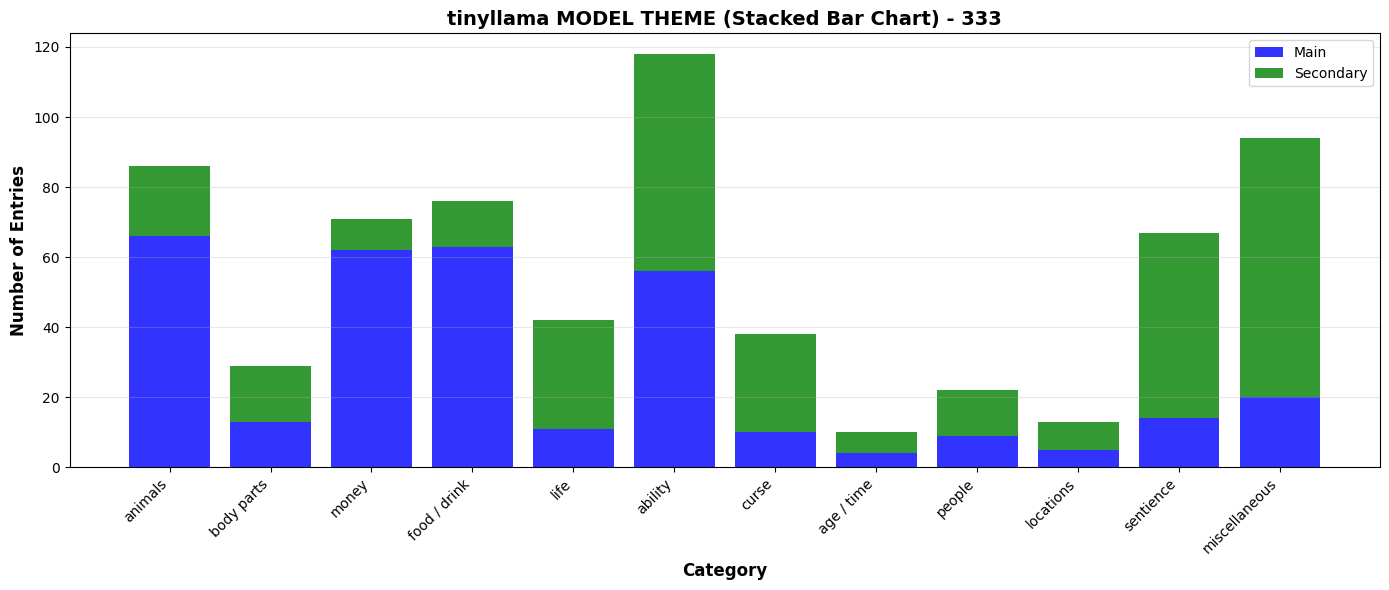

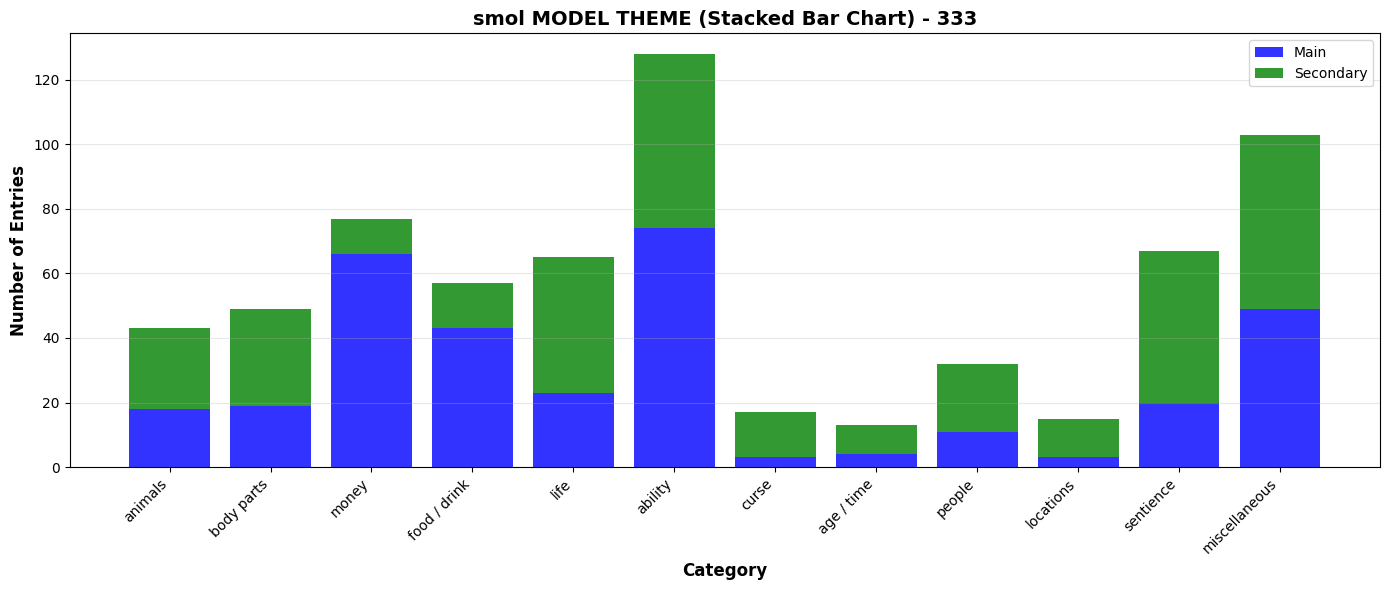

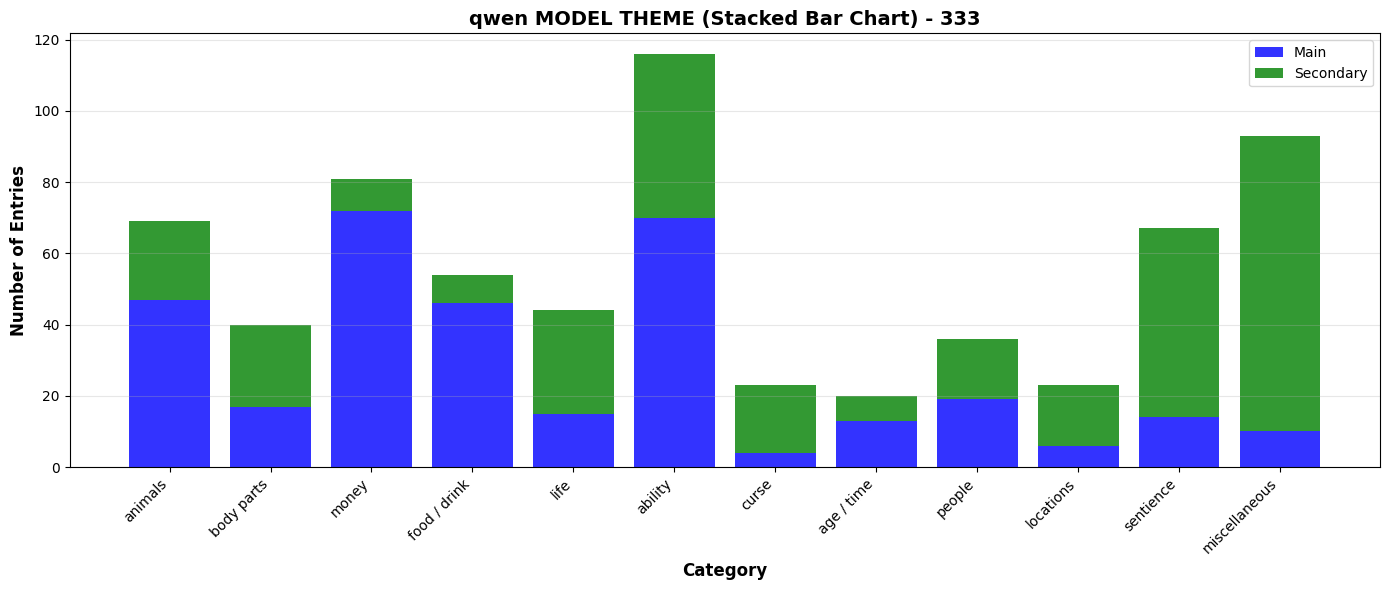

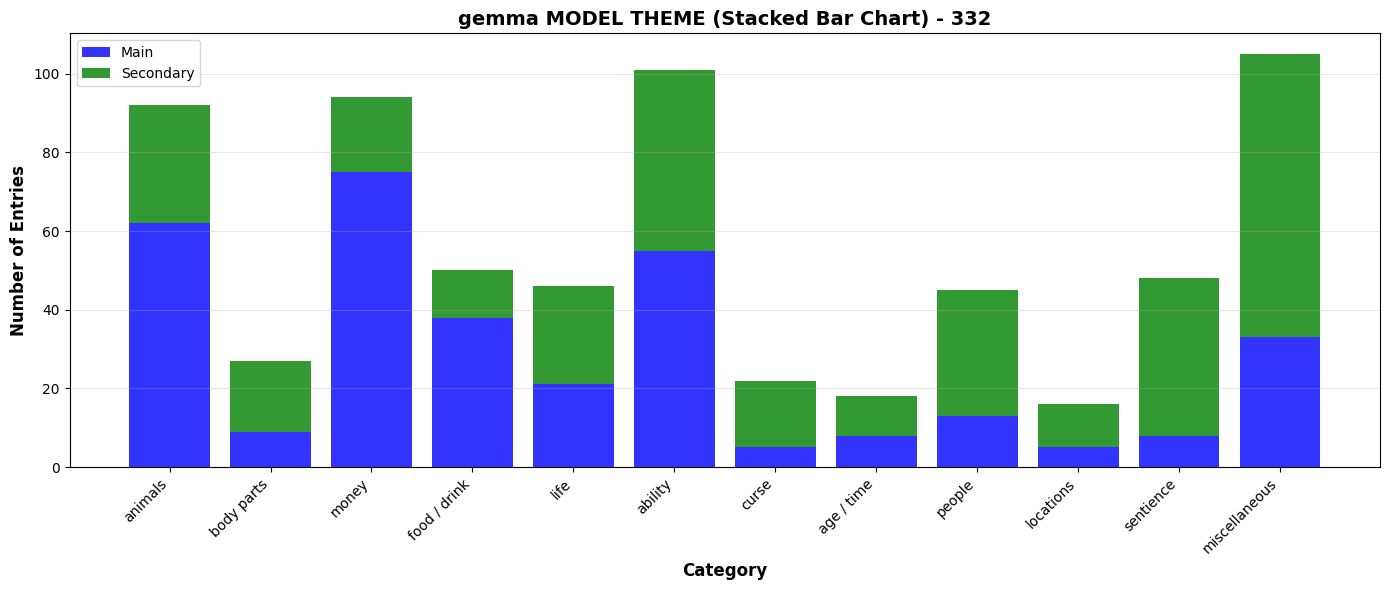

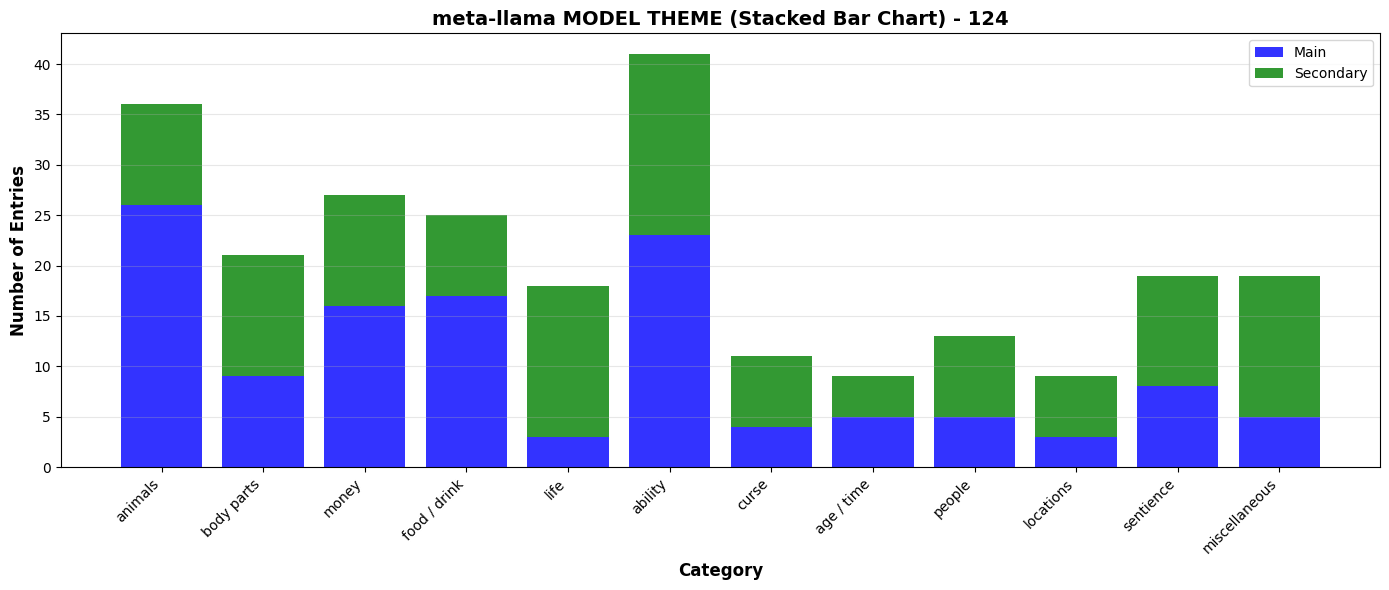

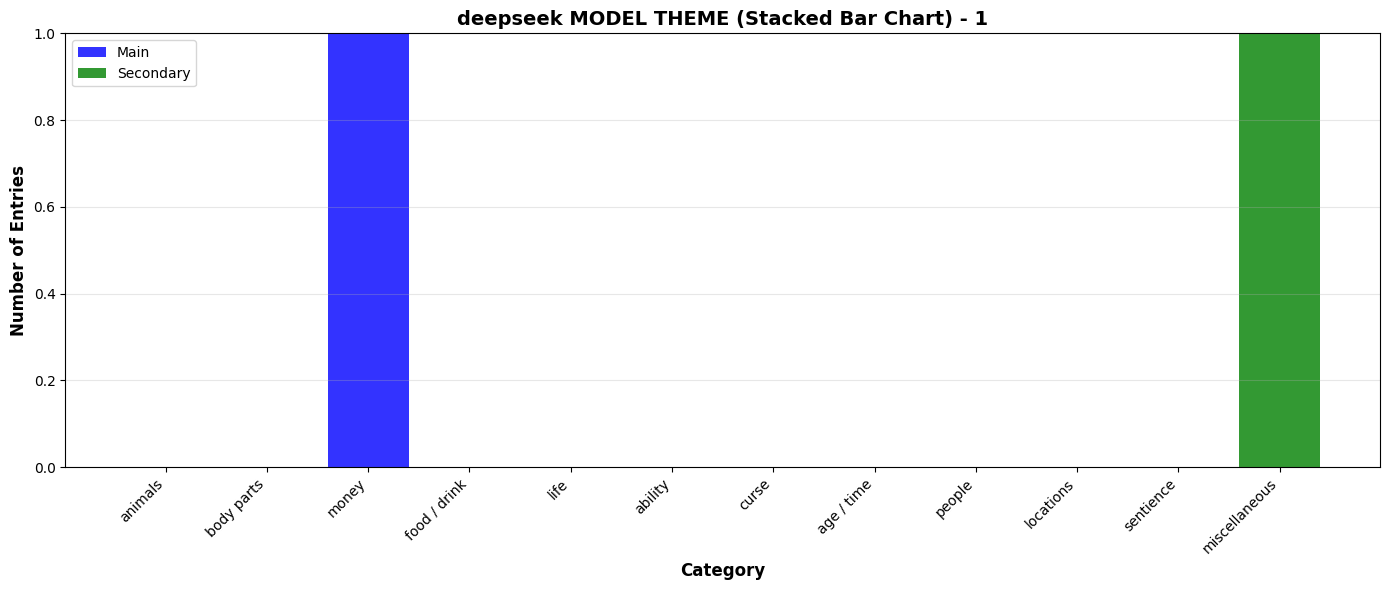

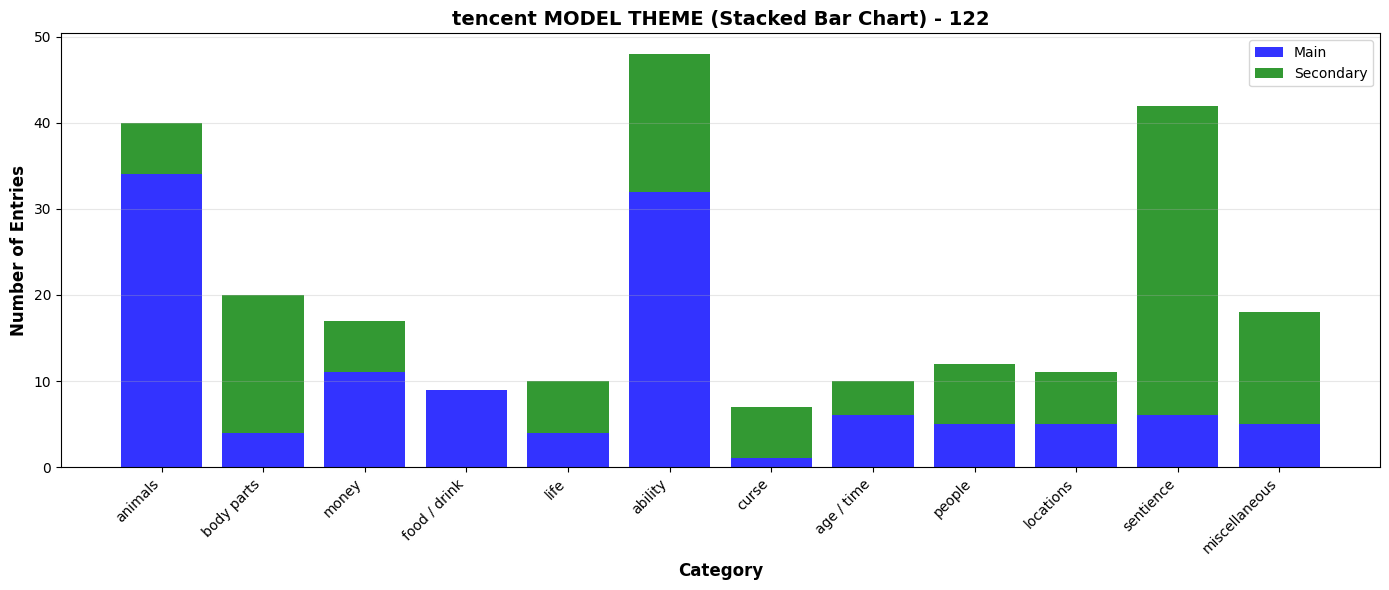

In [7]:

# group by model
MODEL_SET = {}

# group each entry
num_entries = 0
for index, entry in df.iterrows():
    if entry['option_a'] == "Option A" or entry['option_b'] == "Option B":
        continue

    model = entry['model_name']

    # change llama to tinyllama
    if model == "llama":
        model = "tinyllama"
        
    if model not in MODEL_SET:
        MODEL_SET[model] = []
    MODEL_SET[model].append(entry)
    num_entries += 1


# categorize each pairing in each model
CAT_PAIRS = {}
with tqdm(total=num_entries) as pbar:
    for model, entries in MODEL_SET.items():
        CAT_PAIRS[model] = []
        for e in entries:
            CAT_PAIRS[model].append(categorize_pairing({'a':e['option_a'], 'b':e['option_b']}))
            pbar.update(1)


# visualize each model
for model, dat in CAT_PAIRS.items():
    vis_data_cat(dat, model)




## SHOW VOTED DATA

In [8]:


# get the upvoted, downvoted, flagged
with open("upvote_questions.json", 'r') as ud:
    upvote_dat = json.load(ud)


with open("bad_questions.json", 'r') as bd:
    bad_dat = json.load(bd)
    downvote_dat = bad_dat['downvotes']
    flagged_dat = bad_dat['flagged']


# categorize
upvote_cats = []
for u in upvote_dat:
    c = categorize_pairing({'a':u['optionA'],'b':u['optionB']})
    c['model'] = u['MODEL']
    upvote_cats.append(c)

downvote_cats = []
for u in downvote_dat:
    c = categorize_pairing({'a':u['optionA'],'b':u['optionB']})
    c['model'] = u['MODEL']
    downvote_cats.append(c)

flagged_cats = []
for u in flagged_dat:
    c = categorize_pairing({'a':u['optionA'],'b':u['optionB']})
    c['model'] = u['MODEL']
    flagged_cats.append(c)

In [ ]:

# make 2d array for heatmap
# calculate votes with equation
def vote_score_dataframe(ups,downs,flags):
    # x-axis : MODEL
    # y-axis : CATEGORY
    # value = 2*(# upvotes) + -1*(# downvotes) + -3*(# flagged)

    arr_main = np.full((len(CATEGORIES.keys()),len(ALL_MODELS)), 0.0)
    arr_sec = np.full((len(CATEGORIES.keys()),len(ALL_MODELS)), 0.0)
    y_axis = sorted(list(CATEGORIES.keys()))
    x_axis = sorted(ALL_MODELS)

    # upvotes -> +3
    scoring = [3,-1,-3]
    ds = [ups, downs, flags]
    for i in range(3):
        v = ds[i]
        s = scoring[i]
        for u in v:
            model = u['model']
            m_cat = u['main_category']
            s_cat = u['secondary_category']

            # print(f"MODEL: {model} | M_CAT: {m_cat} | S_CAT: {s_cat} | SCORE: {s}")
            # print(u)

            arr_main[y_axis.index(m_cat)][x_axis.index(model)] += s

            arr_sec[y_axis.index(s_cat)][x_axis.index(model)] += s

    # turn into dataframe
    mdf = pd.DataFrame(arr_main, index=y_axis, columns=x_axis)
    sdf = pd.DataFrame(arr_sec, index=y_axis, columns=x_axis)

    return mdf, sdf


In [59]:
main_df, sec_df = vote_score_dataframe(upvote_cats,downvote_cats,flagged_cats)

MODEL: gemma | M_CAT: ability | S_CAT: curse | SCORE: 3
{'a': "Be able to make someone disappear with a thought (you can't teleport anywhere else on earth, but the person is gone for 10 minutes when your power is used)", 'b': 'Make everyone believe that they are not who they really are', 'main_category': 'ability', 'secondary_category': 'curse', 'score': 0.7137, 'model': 'gemma'}
MODEL: smol | M_CAT: body parts | S_CAT: ability | SCORE: 3
{'a': 'Be a knight, but have to wear armor that is made of clay instead of steel', 'b': 'Have no hands', 'main_category': 'body parts', 'secondary_category': 'ability', 'score': 0.6361, 'model': 'smol'}
MODEL: gemma | M_CAT: ability | S_CAT: curse | SCORE: 3
{'a': "Be able to make someone disappear with a thought (you can't teleport anywhere else on earth, but the person is gone for 10 minutes when your power is used)", 'b': 'Make everyone believe that they are not who they really are', 'main_category': 'ability', 'secondary_category': 'curse', 'score

In [ ]:
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.pyplot as plt

def make_asymmetric_cmap(vmin, vmax):
    """
    Builds a diverging colormap where:
    - vmin maps to strong red
    - 0 maps to strong black
    - vmax maps to strong green
    Each half is scaled independently so zero is always black.
    """
    # How far 0 sits between vmin and vmax (0.0 = all negative, 1.0 = all positive)
    zero_point = abs(vmin) / (abs(vmin) + abs(vmax))

    colors = ["red", "black", "green"]
    positions = [0.0, zero_point, 1.0]

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "asymmetric_rdblgn",
        list(zip(positions, colors))
    )
    return cmap


In [94]:
def showHeatmap(m, title):
    
    # cmap2 = mcolors.LinearSegmentedColormap.from_list(
    #     "red_black_green", ["red", "black", "green"]
    # )
    stoplight = seaborn.color_palette("blend:#ff0000,#fff,#00ff00", as_cmap=True)
    vmin = m.min().min()
    vmax = m.max().max()

    # zero_point = abs(vmin) / (abs(vmin) + abs(vmax))

    # colors = ["red", "black", "green"]
    # positions = [0.0, zero_point, 1.0]

    # cmap3 = mcolors.LinearSegmentedColormap.from_list(
    #     "asymmetric_rdblgn",
    #     list(zip(positions, colors))
    # )

    # half = int((maximum + minimum) / 2)
    seaborn.heatmap(main_df, annot=True, cmap=stoplight, center=0,          # anchors black at 0
        vmin=vmin,  # or set a fixed range e.g. vmin=-10
        vmax=vmax)  # e.g. vmax=10)

    # 3. Display
    plt.title(title)
    plt.show()

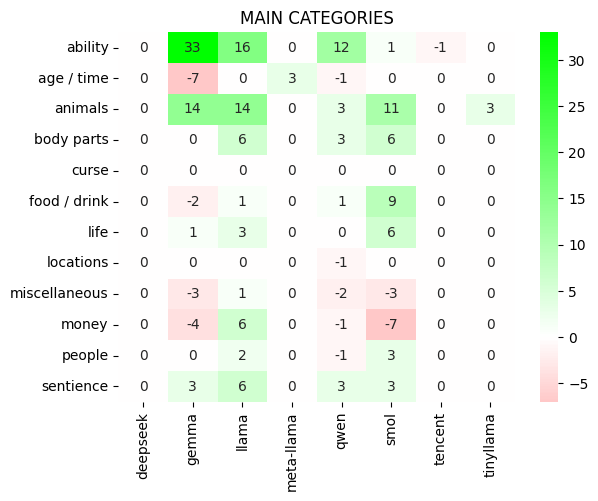

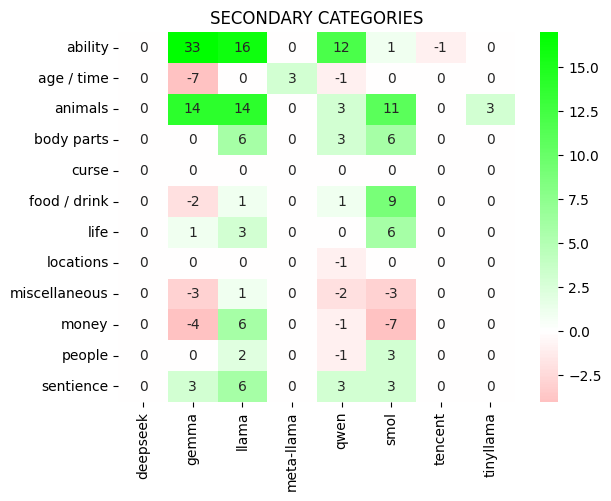

In [95]:
showHeatmap(main_df, "MAIN CATEGORIES")
showHeatmap(sec_df, "SECONDARY CATEGORIES")